In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [6]:
raw_data = pd.read_csv("C:\Documents\AI Usage by College Student 2025\Students Data.csv")

<>:1: SyntaxWarning: invalid escape sequence '\D'
<>:1: SyntaxWarning: invalid escape sequence '\D'
C:\Users\sarah\AppData\Local\Temp\ipykernel_12788\2883009817.py:1: SyntaxWarning: invalid escape sequence '\D'
  raw_data = pd.read_csv("C:\Documents\AI Usage by College Student 2025\Students Data.csv")


In [17]:
raw_data.head()

,Student_Name,College_Name,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,State,Device_Used,Internet_Access,Usage_Category
0,Aarav,Indian Institute of Information Technology,Engineering,4,Gemini,0.9,"Assignments, Coding Help",2,2,No,Copilot,9,Yes,Uttar pradesh,Mobile,Poor,Low Use (< 2 hrs)
1,Vivaan,"Government Ram Bhajan Rai NES College, Jashpur",Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Chhattisgarh,Laptop,Poor,Medium Use (2-5 hrs)
2,Aditya,Dolphin PG Institute of BioMedical & Natural,Science,2,Copilot,3.6,"MCQ Practice, Projects",5,0,No,Gemini,1,No,Uttarakhand,Tablet,Poor,Medium Use (2-5 hrs)
3,Vihaan,Shaheed Rajguru College of Applied Sciences for,Arts,2,Copilot,2.9,Content Writing,5,2,Yes,Gemini,5,No,Delhi ncr,Laptop,High,Medium Use (2-5 hrs)
4,Arjun,Roorkee College of Engineering,Science,1,Gemini,0.9,"Doubt Solving, Resume Writing",1,3,Yes,Other,8,Yes,Uttarakhand,Laptop,Medium,Low Use (< 2 hrs)


In [9]:
# 1. Create the 'Usage_Category' column using conditional logic
bins = [0, 2, 5, raw_data['Daily_Usage_Hours'].max() + 1]
labels = ['Low Use (< 2 hrs)', 'Medium Use (2-5 hrs)', 'High Use (>= 5 hrs)']
raw_data['Usage_Category'] = pd.cut(raw_data['Daily_Usage_Hours'], bins=bins, labels=labels, right=False)
raw_data

,Student_Name,College_Name,Stream,Year_of_Study,AI_Tools_Used,Daily_Usage_Hours,Use_Cases,Trust_in_AI_Tools,Impact_on_Grades,Do_Professors_Allow_Use,Preferred_AI_Tool,Awareness_Level,Willing_to_Pay_for_Access,State,Device_Used,Internet_Access,Usage_Category
0,Aarav,Indian Institute of Information Technology,Engineering,4,Gemini,0.9,"Assignments, Coding Help",2,2,No,Copilot,9,Yes,Uttar pradesh,Mobile,Poor,Low Use (< 2 hrs)
1,Vivaan,"Government Ram Bhajan Rai NES College, Jashpur",Commerce,2,ChatGPT,3.4,Learning new topics,3,-3,Yes,Other,6,No,Chhattisgarh,Laptop,Poor,Medium Use (2-5 hrs)
2,Aditya,Dolphin PG Institute of BioMedical & Natural,Science,2,Copilot,3.6,"MCQ Practice, Projects",5,0,No,Gemini,1,No,Uttarakhand,Tablet,Poor,Medium Use (2-5 hrs)
3,Vihaan,Shaheed Rajguru College of Applied Sciences for,Arts,2,Copilot,2.9,Content Writing,5,2,Yes,Gemini,5,No,Delhi ncr,Laptop,High,Medium Use (2-5 hrs)
4,Arjun,Roorkee College of Engineering,Science,1,Gemini,0.9,"Doubt Solving, Resume Writing",1,3,Yes,Other,8,Yes,Uttarakhand,Laptop,Medium,Low Use (< 2 hrs)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3609,Ishaan,"St. Mira's College for Girls, Pune",Commerce,1,"ChatGPT, Copilot",4.3,"Doubt Solving, Resume Writing",2,2,Yes,Other,2,No,NaN,Mobile,High,Medium Use (2-5 hrs)
3610,Rudra,Roorkee College of Pharmacy,Pharmacy,3,Copilot,3.0,Content Writing,2,1,No,Copilot,5,Yes,NaN,Tablet,Poor,Medium Use (2-5 hrs)
3611,Dhruv,"Bahona College, Jorhat",Agriculture,3,Gemini,2.7,"Exam Prep, Notes",2,1,Yes,Copilot,3,No,NaN,Tablet,Poor,Medium Use (2-5 hrs)
3612,Kabir,Sree Chitra Thirunal College of Engineering,Engineering,4,Gemini,2.7,"Exam Prep, Notes",3,3,Yes,Gemini,3,No,NaN,Laptop,High,Medium Use (2-5 hrs)


Insight 1: Correlation Between Usage and Grade Impact

Goal: Determine if students who spend more time using AI report a higher (or lower) average impact on their grades.

In [10]:
# 2. Group by the new category and calculate the mean grade impact and count
insight_1 = raw_data.groupby('Usage_Category', observed=True).agg(
    Avg_Grade_Impact_Score=('Impact_on_Grades', 'mean'),
    Student_Count=('Impact_on_Grades', 'count')
).reset_index().sort_values(by='Avg_Grade_Impact_Score', ascending=False)

print("--- Insight 1: Average Grade Impact by Usage Level ---")
print(insight_1)

--- Insight 1: Average Grade Impact by Usage Level ---
         Usage_Category  Avg_Grade_Impact_Score  Student_Count
1  Medium Use (2-5 hrs)                0.117031           2290
0     Low Use (< 2 hrs)               -0.189970           1316
2   High Use (>= 5 hrs)               -0.750000              8


INSIGHT 1: VISUALIZATION

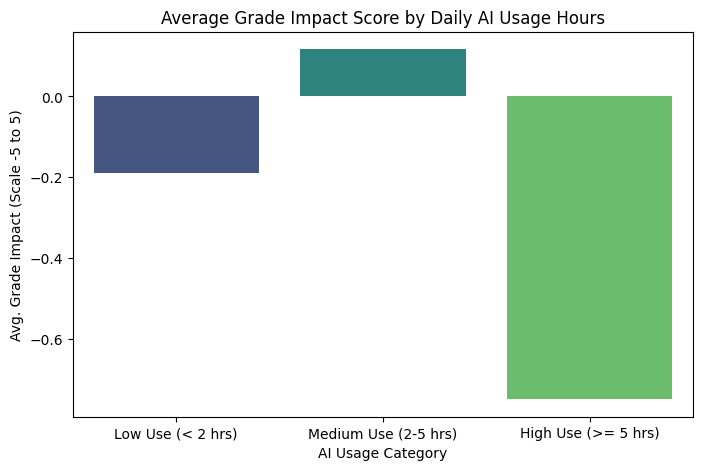

In [18]:
plt.figure(figsize=(8, 5))
sns.barplot(
    x='Usage_Category', 
    y='Avg_Grade_Impact_Score', 
    data=insight_1, 
    palette='viridis',
    hue='Usage_Category',  # Set hue explicitly to the x-variable
    legend=False           # Suppress the redundant legend
)
plt.title('Average Grade Impact Score by Daily AI Usage Hours')
plt.xlabel('AI Usage Category')
plt.ylabel('Avg. Grade Impact (Scale -5 to 5)')
plt.show()

Insight 2: Professor Policy vs. Student Tool Preference

Goal: Identify which preferred tools are used even when professors disallow them.

In [12]:
# 1. Filter the data for cases where professors DO NOT allow AI use
disallowed_use = raw_data[raw_data['Do_Professors_Allow_Use'] == 'No']

# 2. Group by Preferred_AI_Tool and calculate the count and average trust
insight_2 = disallowed_use.groupby('Preferred_AI_Tool').agg(
    Preference_Count=('Preferred_AI_Tool', 'count'),
    Avg_Trust_Score=('Trust_in_AI_Tools', 'mean')
).reset_index().sort_values(by='Preference_Count', ascending=False)

# Filter for significant preference (e.g., more than 10 students)
insight_2 = insight_2[insight_2['Preference_Count'] > 10]

print("\n--- Insight 2: Preferred Tools When Use is DISALLOWED ---")
print(insight_2)


--- Insight 2: Preferred Tools When Use is DISALLOWED ---
  Preferred_AI_Tool  Preference_Count  Avg_Trust_Score
1           ChatGPT               480         3.004167
3           Copilot               471         3.138004
4            Gemini               429         3.004662
5             Other               338         3.133136
2            Claude                89         2.966292
0              Bard                79         2.911392


In [13]:
# 1. Filter the data for cases where professors DO allow AI use
allowed_use = raw_data[raw_data['Do_Professors_Allow_Use'] == 'Yes']

# 2. Group by Preferred_AI_Tool and calculate the count and average trust
insight_2 = allowed_use.groupby('Preferred_AI_Tool').agg(
    Preference_Count=('Preferred_AI_Tool', 'count'),
    Avg_Trust_Score=('Trust_in_AI_Tools', 'mean')
).reset_index().sort_values(by='Preference_Count', ascending=False)

# Filter for significant preference (e.g., more than 10 students)
insight_2 = insight_2[insight_2['Preference_Count'] > 10]

print("\n--- Insight 2: Preferred Tools When Use is ALLOWED ---")
print(insight_2)


--- Insight 2: Preferred Tools When Use is ALLOWED ---
  Preferred_AI_Tool  Preference_Count  Avg_Trust_Score
4            Gemini               425         3.110588
5             Other               419         2.871122
1           ChatGPT               379         2.905013
3           Copilot               365         3.098630
0              Bard                72         2.972222
2            Claude                68         2.838235


Insight 3: The Most Common Use Cases for AI

Goal: Understand the primary academic activities students are using AI for.

In [15]:
# 1. Group by Use_Cases and calculate the count and average awareness
insight_3 = raw_data.groupby('Use_Cases').agg(
    Total_Student_Use_Count=('Use_Cases', 'count'),
    Avg_Awareness=('Awareness_Level', 'mean')
).reset_index().sort_values(by='Total_Student_Use_Count', ascending=False).head(5) # Show top 5

print("\n--- Insight 3: Top 5 Most Common AI Use Cases ---")
print(insight_3)


--- Insight 3: Top 5 Most Common AI Use Cases ---
                    Use_Cases  Total_Student_Use_Count  Avg_Awareness
1    Assignments, Coding Help                      534       5.747191
254    MCQ Practice, Projects                      470       5.938298
144          Exam Prep, Notes                      451       5.707317
75            Content Writing                      428       5.862150
181       Learning new topics                      416       6.233173


Insight 4: High Impact/Low Awareness Students (Risk Group)

### Goal: Identify students with a significant negative grade impact and low awareness.

In [16]:
# 1. Define the High-Risk conditions:
#    a) Bad Grade Impact: Impact_on_Grades <= -3
#    b) Low Awareness: Awareness_Level <= 2

high_risk_group = raw_data[
    (raw_data['Impact_on_Grades'] <= -3) &
    (raw_data['Awareness_Level'] <= 2)
]

# 2. Calculate the count and average hours for this group
high_risk_count = high_risk_group.shape[0]
avg_risk_hours = high_risk_group['Daily_Usage_Hours'].mean()

print("\n--- Insight 4: High Risk Group (Bad Impact & Low Awareness) ---")
print(f"Total High-Risk Students (Impact <= -3 AND Awareness <= 2): {high_risk_count}")
print(f"Average Daily Usage Hours for Risk Group: {avg_risk_hours:.2f} hours")


--- Insight 4: High Risk Group (Bad Impact & Low Awareness) ---
Total High-Risk Students (Impact <= -3 AND Awareness <= 2): 92
Average Daily Usage Hours for Risk Group: 2.37 hours


Insight 5: Trust Levels Across Different AI Tools
### Goal: Compare the average trust score (Trust_in_AI_Tools, on a scale like 1-5) that students place in their different preferred AI tools. This helps identify which tools inspire the most confidence.

In [19]:
# Group by preferred tool and calculate the mean trust score and count
insight_5 = raw_data.groupby('Preferred_AI_Tool').agg(
    Avg_Trust_Score=('Trust_in_AI_Tools', 'mean'),
    Student_Count=('Preferred_AI_Tool', 'count')
).reset_index().sort_values(by='Avg_Trust_Score', ascending=False)

# Filter out tools with very low usage count for reliable averages
insight_5 = insight_5[insight_5['Student_Count'] >= 20] # Adjust the count threshold as needed

print("\n--- Insight 5: Average Trust Score by Preferred AI Tool ---")
print(insight_5)


--- Insight 5: Average Trust Score by Preferred AI Tool ---
  Preferred_AI_Tool  Avg_Trust_Score  Student_Count
3           Copilot         3.120813            836
4            Gemini         3.057377            854
5             Other         2.988111            757
1           ChatGPT         2.960419            859
0              Bard         2.940397            151
2            Claude         2.910828            157


Analysis Tip (Visualization)

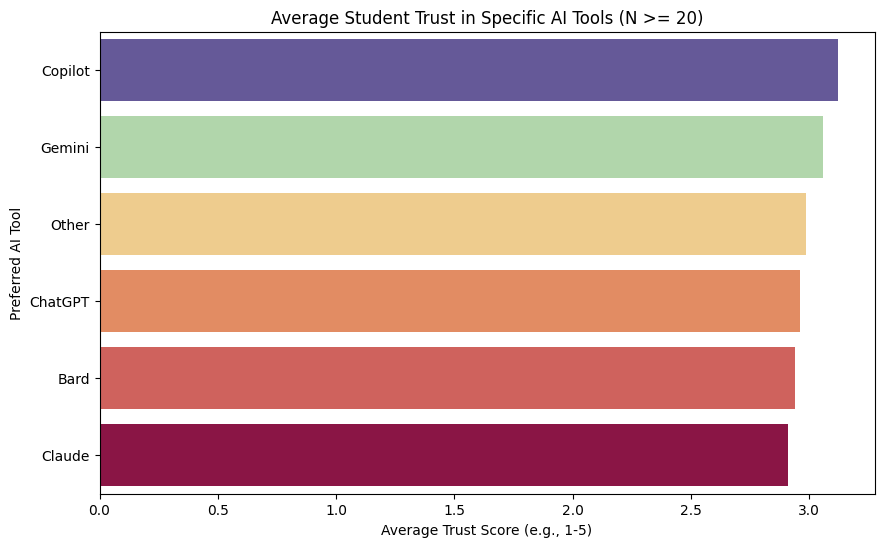

In [21]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Avg_Trust_Score', y='Preferred_AI_Tool', data=insight_5, palette='Spectral', hue='Avg_Trust_Score',  # Set hue explicitly to the x-variable
    legend=False  )
plt.title('Average Student Trust in Specific AI Tools (N >= 20)')
plt.xlabel('Average Trust Score (e.g., 1-5)')
plt.ylabel('Preferred AI Tool')
plt.show()

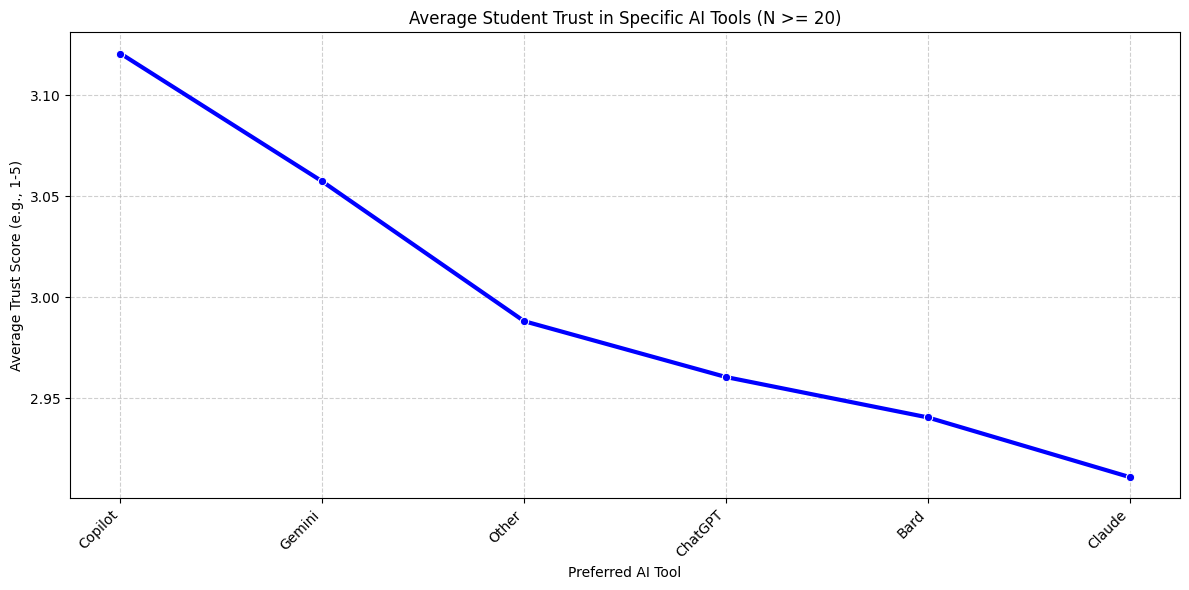

In [23]:
plt.figure(figsize=(12, 6))

# 1. Change sns.barplot to sns.lineplot to create a "curvy" effect.
# 2. Swap the X and Y axes: put the categorical tool names on the X-axis for a conventional look.
# 3. Sort the data first so the line connects points in a meaningful (e.g., descending score) order.

sns.lineplot(
    x='Preferred_AI_Tool',
    y='Avg_Trust_Score',
    data=insight_5.sort_values(by='Avg_Trust_Score', ascending=False),
    marker='o',          # Adds circles at each data point
    linestyle='-',       # Draws a connecting line (the "curve")
    color='blue',
    linewidth=3          # Makes the line thicker for better visibility
)

plt.title('Average Student Trust in Specific AI Tools (N >= 20)')
plt.xlabel('Preferred AI Tool')
plt.ylabel('Average Trust Score (e.g., 1-5)')

# Rotate X-axis labels to prevent overlap, as tool names are usually long
plt.xticks(rotation=45, ha='right') 

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout() # Adjusts plot to ensure all labels fit
plt.show()

Insight 6: Impact on Grades by Awareness Level

### Goal: Investigate whether higher student awareness of AI principles (ethics, limitations, proper use) correlates with a less negative or more positive impact on their grades.

In [24]:
# 1. Group the data by Awareness_Level (e.g., scale 1-5)
# 2. Calculate the average impact on grades for each level
insight_6 = raw_data.groupby('Awareness_Level', observed=True).agg(
    Avg_Grade_Impact=('Impact_on_Grades', 'mean'),
    Student_Count=('Awareness_Level', 'count')
).reset_index()

print("\n--- Insight 6: Average Grade Impact by Awareness Level ---")
print(insight_6)


--- Insight 6: Average Grade Impact by Awareness Level ---
   Awareness_Level  Avg_Grade_Impact  Student_Count
0                1          0.141026            312
1                2          0.000000            347
2                3          0.290055            362
3                4         -0.090909            275
4                5         -0.129139            302
5                6         -0.322129            357
6                7          0.161039            385
7                8         -0.180851            376
8                9          0.146868            463
9               10         -0.045977            435


Insight 7: Most Negative Use Cases

### Goal: Pinpoint the specific AI use cases that are most frequently associated with a severely negative impact on grades (Impact_on_Grades $\le -3$).

In [26]:
# 1. Filter for students who reported a severely negative impact
negative_impact_data = raw_data[raw_data['Impact_on_Grades'] <= -3]

# 2. Count how often each 'Use_Cases' appears in this negative group
insight_7 = negative_impact_data['Use_Cases'].value_counts().reset_index()
insight_7.columns = ['Use_Cases', 'Negative_Impact_Count']

# 3. Calculate the average usage hours for context
insight_7_context = negative_impact_data.groupby('Use_Cases')['Daily_Usage_Hours'].mean().reset_index()
insight_7 = pd.merge(insight_7, insight_7_context, on='Use_Cases')

print("\n--- Insight 7: Top Use Cases Linked to Severe Negative Grade Impact (Impact <= -3) ---")
print(insight_7.sort_values(by='Negative_Impact_Count', ascending=False).head(5))


--- Insight 7: Top Use Cases Linked to Severe Negative Grade Impact (Impact <= -3) ---
                  Use_Cases  Negative_Impact_Count  Daily_Usage_Hours
0    MCQ Practice, Projects                     80           2.182500
1          Exam Prep, Notes                     78           2.201282
2  Assignments, Coding Help                     75           2.390667
3       Learning new topics                     66           2.421212
4           Content Writing                     50           2.694000


VISUALIZATION

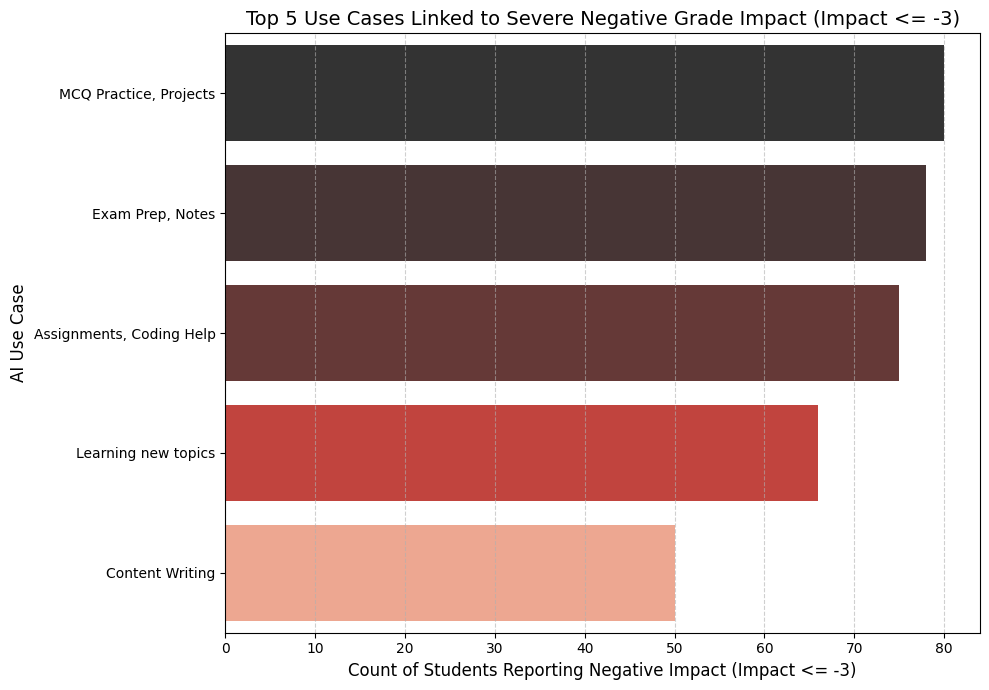

In [37]:
# --- 1. Data Preparation (Ensure this runs first to create insight_7) ---

# Filter for students who reported a severely negative impact (Impact_on_Grades <= -3)
negative_impact_data = raw_data[raw_data['Impact_on_Grades'] <= -3]

# Count how often each 'Use_Cases' appears in this negative group
insight_7 = negative_impact_data['Use_Cases'].value_counts().reset_index()
insight_7.columns = ['Use_Cases', 'Negative_Impact_Count']

# Merge with average usage hours for context (optional for plotting, but useful for analysis)
insight_7_context = negative_impact_data.groupby('Use_Cases')['Daily_Usage_Hours'].mean().reset_index()
insight_7 = pd.merge(insight_7, insight_7_context, on='Use_Cases')

# Sort the data and select the top 5 for plotting
top_5_insight_7 = insight_7.sort_values(by='Negative_Impact_Count', ascending=False).head(5)

# --- 2. Visualization Code ---

plt.figure(figsize=(10, 7))

sns.barplot(
    x='Negative_Impact_Count', 
    y='Use_Cases', 
    data=top_5_insight_7, 
    palette='Reds_d',
    hue='Negative_Impact_Count',  # Set hue explicitly to the x-variable
    legend=False  # Using a sequential red palette for negative impact
)

plt.title('Top 5 Use Cases Linked to Severe Negative Grade Impact (Impact <= -3)', fontsize=14)
plt.xlabel('Count of Students Reporting Negative Impact (Impact <= -3)', fontsize=12)
plt.ylabel('AI Use Case', fontsize=12)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()